In [ ]:
# import pandas as pd

# file_path = "/kaggle/input/datasets/carlosgdcj/genius-song-lyrics-with-language-information/song_lyrics.csv"

# # Load dataset
# df = pd.read_csv(file_path)

# # Show all columns
# print("Columns in dataset:")
# print(df.columns.tolist())

# # Basic structure info
# print("\nDataset Info:")
# print(df.info())

# # Summary statistics (for numeric columns)
# print("\nStatistical Summary:")
# print(df.describe(include='all'))

# # Check missing values per column
# print("\nMissing Values:")
# print(df.isnull().sum())

# # Show first few rows
# print("\nSample Data:")
# print(df.head())

We keep only lyrics, language, artist, and year because the goal is to learn meaningful semantic representations of songs from text, where lyrics is the primary input for embedding, language helps filter and control the dataset for multilingual consistency (English and Bangla), artist can provide optional stylistic grouping signals for later analysis, and year allows temporal interpretation if needed, while all other columns like title, views, id, and language detection fields are either identifiers, noisy metadata, or redundant/conflicting signals that do not contribute to semantic feature learning and may introduce bias or noise in clustering. Missing values in the kept columns are handled by dropping rows with missing lyrics because lyrics are the core input and cannot be imputed meaningfully, while other missing values (like artist or year) can either be safely left as NaN or optionally filled with placeholders (e.g., "unknown" for artist or median year) depending on whether you want to preserve dataset size or ensure cleaner structured metadata for analysis.

In [ ]:
# import pandas as pd
# import re

# # Load data
# df = pd.read_csv(file_path)

# # Keep only useful columns
# # df = df[['lyrics', 'language', 'artist', 'year']]

# df = df[['lyrics', 'language']]

# # Drop missing lyrics
# df = df.dropna(subset=['lyrics'])

# # Filter valid languages (English + Bangla)
# df = df[df['language'].isin(['en', 'bn'])]

In [ ]:
# print("\nMissing Values:")
# print(df.isnull().sum())
# # Basic structure info
# print("\nDataset Info:")
# print(df.info())
# # Summary statistics (for numeric columns)
# print("\nStatistical Summary:")
# print(df.describe(include='all'))

In [ ]:
# counts = df['language'].value_counts()
# ratio = df['language'].value_counts(normalize=True) * 100

# print("Counts:\n", counts)
# print("\nPercentage:\n", ratio)

In [ ]:
# df[df['language'] == 'bn']['lyrics'].sample(5, random_state=42)

In [ ]:

# import re

# def clean_lyrics(text):
#     text = str(text).lower()
#     text = re.sub(r'[^a-zA-Z\u0980-\u09FF\s]', ' ', text)
#     text = re.sub(r'\s+', ' ', text).strip()
#     return text

# df['lyrics'] = df['lyrics'].apply(clean_lyrics)    #overwriting the original lyrics to save spaces
# df = df[df['lyrics'].str.strip() != '']   #It removes rows where lyrics become empty after cleaning.
# df = df[df['lyrics'].str.len() > 20] 

In [ ]:
df[df['language'] == 'bn']['lyrics'].sample(5, random_state=42)

In [ ]:
# import pandas as pd


# df1 = pd.read_csv('/kaggle/input/datasets/shakirulhasan/bangla-song-lyrics/BanglaSongLyrics.csv')
# df2 = pd.read_csv('/kaggle/input/datasets/meherabhasansajid/bangla-song-lyrics-dataset-with-genres-and-artists/Bangla_song_lyrics.csv')


# print("DF1 columns:", df1.columns)
# print("DF2 columns:", df2.columns)

# print(df1['lyrics'].nunique())
# print(df2['lyrics'].nunique())

In [ ]:
# # Keep only lyrics
# df1 = df1[['lyrics']]
# df2 = df2[['lyrics']]

# # Add language column
# df1['language'] = 'bn'
# df2['language'] = 'bn'

# df_bn = pd.concat([df1, df2], ignore_index=True)

# df_bn['lyrics'] = df_bn['lyrics'].apply(clean_lyrics)
# df_bn = df_bn[df_bn['lyrics'].str.strip() != '']
# df_bn = df_bn[df_bn['lyrics'].str.split().str.len() > 20]

# df_bn = df_bn.drop_duplicates(subset=['lyrics'])

# print(df_bn.shape)
# df_bn.head()

In [ ]:
df_final = pd.concat([df, df_bn], ignore_index=True)

In [ ]:
# counts = df_final['language'].value_counts()
# ratio = df_final['language'].value_counts(normalize=True) * 100

# print("Counts:\n", counts)
# print("\nPercentage:\n", ratio)

In [ ]:
# df_en = df_final[df_final['language'] == 'en'].sample(n=11000, random_state=42)
# df_bn = df_final[df_final['language'] == 'bn']

# df_balanced = pd.concat([df_en, df_bn], ignore_index=True)

We merged additional Bangla lyric datasets to address the severe class imbalance in the original data, where English overwhelmingly dominated and Bangla was underrepresented. This imbalance would bias the VAE and clustering models toward English patterns, preventing meaningful learning of Bangla features. To ensure a fair and effective hybrid language analysis, we then downsampled the English data to match the scale of the Bangla dataset. This creates a more balanced corpus, improves clustering quality, and leads to more reliable evaluation and visualization results.


In [ ]:
# print(df_balanced['language'].value_counts())

In [ ]:
# df_balanced.to_csv("/kaggle/working/hybrid_balanced_song_lyrics.csv", index=False)

In [1]:
import pandas as pd

In [ ]:
#df_balanced = pd.read_csv("/kaggle/input/datasets/mesmsr/hybrid-balanced-lyrics-dataset/hybrid_balanced_song_lyrics.csv")

In [2]:
import pandas as pd

# load
df = pd.read_csv("/kaggle/input/datasets/mesmsr/hybrid-balanced-lyrics-dataset/hybrid_balanced_song_lyrics.csv")

# drop missing
df = df.dropna(subset=['lyrics'])

# ensure string type + clean whitespace issues
df['lyrics'] = df['lyrics'].astype(str).str.strip()

# remove empty lyrics after strip
df = df[df['lyrics'] != '']

# remove extremely short lyrics (noise filter)
df = df[df['lyrics'].str.split().str.len() > 5]

# remove duplicates
df = df.drop_duplicates(subset=['lyrics'])

# final check
print(df.shape)
print(df['language'].value_counts())
df.head()

(21966, 2)
language
en    10997
bn    10969
Name: count, dtype: int64


,lyrics,language
0,verse one by one our defences were foiled in t...,en
1,verse her name was anna last name was rexi she...,en
2,verse i think i ll take my chances i think i l...,en
3,verse sleepless i don t know i feel this way i...,en
4,intro sure sure sure sure you know what time i...,en


We apply df = df[df['clean_lyrics'].str.len() > 20] to remove extremely short or incomplete lyrics entries (such as repeated words, fragments, or noise) because very short text samples do not contain enough semantic information for meaningful embedding learning, which can distort the VAE latent space and reduce clustering quality by introducing unstable or uninformative representations.

In [3]:
!pip install -q -U transformers sentence-transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 76.7 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 101.7 MB/s eta 0:00:0000:01


In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/LaBSE')

modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

In [ ]:
!pip install torch==2.2.0+cu118 torchvision==0.17.0+cu118 torchaudio==2.2.0+cu118 \
    --index-url https://download.pytorch.org/whl/cu118 -q



In [4]:
!pip install "numpy<2" -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 85.6 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
c

In [5]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

Torch version: 2.10.0+cu128
CUDA available: True
Device: Tesla T4


In [6]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using: {device} — {torch.cuda.get_device_name(0)}")

from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/LaBSE', device=device)

texts = df['lyrics'].tolist()

embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(embeddings.shape)

Using: cuda — Tesla T4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/687 [00:00<?, ?it/s]

(21966, 768)


In [8]:
import numpy as np

np.save("/kaggle/working/lyrics_embeddings.npy", embeddings)

In [10]:
embeddings = np.load("/kaggle/working/lyrics_embeddings.npy")

In [11]:
import torch
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, input_dim=768, latent_dim=64):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.mu = nn.Linear(128, latent_dim)
        self.logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 128)
        self.fc4 = nn.Linear(128, 256)
        self.fc5 = nn.Linear(256, input_dim)

        self.relu = nn.ReLU()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        h = self.relu(self.fc2(h))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.relu(self.fc3(z))
        h = self.relu(self.fc4(h))
        return self.fc5(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [12]:
from sklearn.preprocessing import StandardScaler
import torch

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

data_tensor = torch.tensor(embeddings_scaled, dtype=torch.float32)

In [22]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

dataset = TensorDataset(data_tensor)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = VAE(input_dim=768, latent_dim=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def loss_fn(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon_x, x)
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld

epochs = 300

for epoch in range(epochs):
    total_loss = 0
    for batch in loader:
        x = batch[0].to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = loss_fn(recon, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 169.9353
Epoch 2, Loss: 159.1783
Epoch 3, Loss: 155.3087
Epoch 4, Loss: 152.5197
Epoch 5, Loss: 151.5393
Epoch 6, Loss: 150.6841
Epoch 7, Loss: 149.6023
Epoch 8, Loss: 148.8436
Epoch 9, Loss: 148.4767
Epoch 10, Loss: 147.8855
Epoch 11, Loss: 147.4358
Epoch 12, Loss: 147.2434
Epoch 13, Loss: 147.0124
Epoch 14, Loss: 146.9120
Epoch 15, Loss: 146.7582
Epoch 16, Loss: 146.7519
Epoch 17, Loss: 146.6082
Epoch 18, Loss: 146.5169
Epoch 19, Loss: 146.5113
Epoch 20, Loss: 146.3457
Epoch 21, Loss: 146.3234
Epoch 22, Loss: 146.2340
Epoch 23, Loss: 146.1364
Epoch 24, Loss: 146.1211
Epoch 25, Loss: 146.0398
Epoch 26, Loss: 145.9858
Epoch 27, Loss: 145.9462
Epoch 28, Loss: 145.9020
Epoch 29, Loss: 145.8357
Epoch 30, Loss: 145.7742
Epoch 31, Loss: 145.7486
Epoch 32, Loss: 145.7512
Epoch 33, Loss: 145.6631
Epoch 34, Loss: 145.6838
Epoch 35, Loss: 145.6894
Epoch 36, Loss: 145.6587
Epoch 37, Loss: 145.5841
Epoch 38, Loss: 145.5266
Epoch 39, Loss: 145.5588
Epoch 40, Loss: 145.5167
Epoch 41,

In [24]:
model.eval()

with torch.no_grad():
    mu, _ = model.encode(data_tensor.to(device))
    latent_vectors = mu.cpu().numpy()

print(latent_vectors.shape)

(21966, 64)


In [25]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(latent_vectors)

In [26]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

sil_score = silhouette_score(latent_vectors, clusters)
ch_score = calinski_harabasz_score(latent_vectors, clusters)

print("Silhouette Score:", sil_score)
print("Calinski-Harabasz Score:", ch_score)

# LaBSE embeddings

# Silhouette Score: 0.24929687        100 epochs
# Calinski-Harabasz Score: 7383.9136

# Silhouette Score: 0.25107333        300 epochs
# Calinski-Harabasz Score: 7514.2847

Silhouette Score: 0.25107333
Calinski-Harabasz Score: 7514.2847


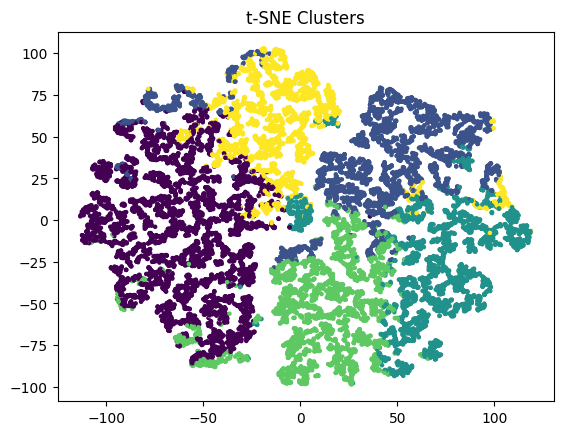

In [19]:
# Clusters after 100 epoch

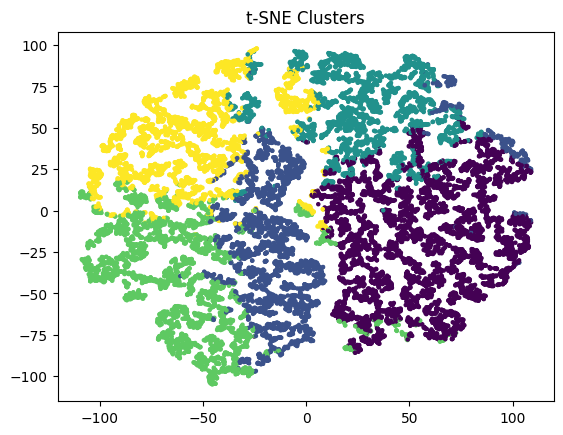

In [27]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(latent_vectors)

plt.scatter(reduced[:,0], reduced[:,1], c=clusters, cmap='viridis', s=5)
plt.title("t-SNE Clusters")
plt.show()

In [20]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Reduce dimensions
pca = PCA(n_components=64, random_state=42)
pca_features = pca.fit_transform(embeddings)

# KMeans
kmeans_pca = KMeans(n_clusters=5, random_state=42)
clusters_pca = kmeans_pca.fit_predict(pca_features)

# Evaluation
sil_pca = silhouette_score(pca_features, clusters_pca)
ch_pca = calinski_harabasz_score(pca_features, clusters_pca)

print("PCA Silhouette:", sil_pca)
print("PCA CH Score:", ch_pca)

PCA Silhouette: 0.037078295
PCA CH Score: 1592.935


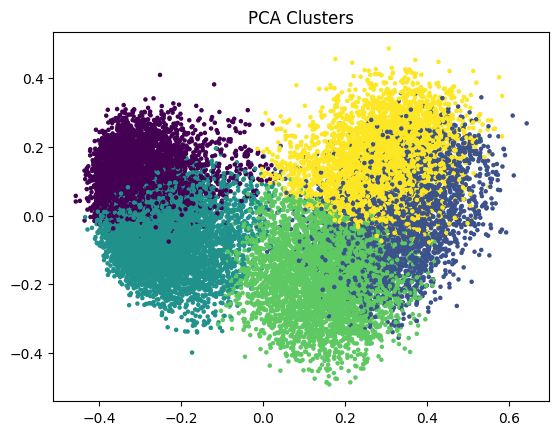

In [21]:
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2)
reduced_pca = pca_2d.fit_transform(embeddings)

plt.scatter(reduced_pca[:,0], reduced_pca[:,1], c=clusters_pca, s=5)
plt.title("PCA Clusters")
plt.show()

MFCC = “how the song sounds over time”
Spectrogram = “visual representation of sound energy”